## 원본/SMOTE/가중치 파라미터 비교 →여부 결정→ HP튜닝 → OOF 임계값 탐색 → 최종 평가

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform
SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


In [11]:
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 파생변수 추가 버전
type1_df = pd.read_csv('../../data/df_type2_파생변수추가.csv')
type1_df['Pressure_Diff_ratio'] = type1_df['Casting_Pressure'] / type1_df['Cylinder_Pressure']

NEW_DERIVED = [
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'    
]

FEATURES = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
    'Pressure_Rise_Time', 'Casting_Pressure', 'Cylinder_Pressure',
    'Spray_Time', 'Spray_1_Time', 'Spray_2_Time',
    'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity',
    'Pressure_Diff_ratio',
    # 신규 파생변수
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'   
]

X = type1_df[FEATURES].copy()
y = type1_df['Defect_Status'].copy()

print(f"피처 수: {len(FEATURES)}개 (원본 21 + 신규 파생변수 {len(NEW_DERIVED)}개)")
print(f"타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")

피처 수: 26개 (원본 21 + 신규 파생변수 5개)
타겟 분포 → 양품: 1467 / 불량: 497 (25.3%)


## STEP 1. 피처 및 타겟 정의

## STEP 2. Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

pos_weight = (y_train==0).sum() / (y_train==1).sum()

print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight:.2f}")

훈련셋: 1571행  |  테스트셋: 393행
훈련셋 불량률: 25.3%  |  테스트셋 불량률: 25.2%
scale_pos_weight: 2.95


In [13]:
from sklearn.ensemble import IsolationForest

# 수치형 컬럼만 선택
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

iso = IsolationForest(contamination=0.01, random_state=SEED)
iso.fit(X_train_num)
train_anomaly = iso.predict(X_train_num)
test_anomaly = iso.predict(X_test_num)

print(f"훈련셋 이상치: {(train_anomaly == -1).sum()}건 ({(train_anomaly == -1).mean()*100:.1f}%)")
print(f"테스트셋 이상치: {(test_anomaly == -1).sum()}건 ({(test_anomaly == -1).mean()*100:.1f}%)")

X_train_iso = X_train_num[train_anomaly == 1]
y_train_iso = y_train[train_anomaly == 1]
print(f"\nIsolation Forest 후 훈련셋: {X_train_iso.shape[0]}행")
print(f"불량률: {y_train_iso.mean()*100:.1f}%")

훈련셋 이상치: 15건 (1.0%)
테스트셋 이상치: 1건 (0.3%)

Isolation Forest 후 훈련셋: 1556행
불량률: 25.2%


## STEP 3. 베이스라인 모델 비교

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr,r,p,f1 = best; ok = True
    else:
        thr,r,p,f1 = best_any; ok = False
    return thr, r, p, f1, ok


def find_threshold_from_oof(model_template, X_tr, y_tr, n_splits=5, xgb_ref_cols=None):
    """
    5-Fold OOF 확률로 임계값 결정 — test 정보 불사용 (데이터 누수 방지)
    임계값을 test로 최적화하면 성능이 낙관적으로 편향되므로, OOF로 결정 후 test에 고정 적용.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx], X_r.iloc[val_idx]
        yf_tr = y_r.iloc[tr_idx]
        if xgb_ref_cols is not None:
            Xf_tr  = pd.get_dummies(Xf_tr).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_tr, yf_tr)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr


def find_threshold_from_oof_smote(model_template, X_tr, y_tr, strategy,
                                   n_splits=5, xgb_ref_cols=None):
    """
    SMOTE 포함 OOF — 각 폴드 train에만 SMOTE 적용 (val에는 원본 그대로)
    SMOTE를 전체 train에 먼저 적용 후 split하면 val 정보가 합성샘플에 섞여 누수 발생.
    """
    from imblearn.over_sampling import SMOTE as _SMOTE
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X_r = X_tr.reset_index(drop=True)
    y_r = y_tr.reset_index(drop=True)
    y_oof = np.zeros(len(y_r))
    for tr_idx, val_idx in skf.split(X_r, y_r):
        Xf_tr, Xf_val = X_r.iloc[tr_idx].copy(), X_r.iloc[val_idx].copy()
        yf_tr = y_r.iloc[tr_idx].copy()
        sm = _SMOTE(sampling_strategy=strategy, random_state=SEED)
        Xf_sm, yf_sm = sm.fit_resample(Xf_tr, yf_tr)
        if xgb_ref_cols is not None:
            Xf_sm  = pd.get_dummies(Xf_sm).reindex(columns=xgb_ref_cols, fill_value=0)
            Xf_val = pd.get_dummies(Xf_val).reindex(columns=xgb_ref_cols, fill_value=0)
        m = model_template.__class__(**model_template.get_params())
        m.fit(Xf_sm, yf_sm)
        y_oof[val_idx] = m.predict_proba(Xf_val)[:, 1]
    thr, _, _, _, _ = find_best_threshold_constrained(y_r, y_oof)
    return thr


# XGBoost용 원-핫
X_train_xgb = pd.get_dummies(X_train)
X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

baseline_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=pos_weight, n_estimators=200,
        random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
}

# ※ 베이스라인은 탐색 목적 — 임계값은 test 기준 (상대 비교용)
baseline_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        model.fit(X_train, y_train)
        yp = model.predict_proba(X_test)[:,1]

    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    baseline_results.append({
        '모델': name, '임계값(탐색용)': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

result_df = pd.DataFrame(baseline_results).sort_values('F1-Score', ascending=False)
display(result_df)

  ✅ Random Forest 완료 | thr=0.16 | Recall=0.828 | F1=0.488
  ✅ XGBoost 완료 | thr=0.15 | Recall=0.586 | F1=0.479
  ✅ LightGBM 완료 | thr=0.07 | Recall=0.576 | F1=0.449


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.16,0.8283,0.3460,0.4881,0.7148,✅
1,XGBoost,0.15,0.5859,0.4056,0.4793,0.6988,❌
2,LightGBM,0.07,0.5758,0.3677,0.4488,0.6926,❌


## STEP 4. SMOTE 적용 여부 결정 → HP 튜닝 → OOF 임계값 탐색 → 최종 평가

> **흐름**: SMOTE strategy 실험(baseline 파라미터) → SMOTE 여부·strategy 결정 → HP 튜닝(결정된 데이터) → OOF 임계값 탐색 → 최종 모델 선정
>
> **이유**: HP 튜닝은 실제 학습 환경과 동일한 데이터 분포에서 해야 최적 파라미터가 유효함.  
> SMOTE 결정 전에 튜닝하면 원본 불균형 기준 파라미터가 SMOTE 데이터에서 최적이 아닐 수 있음.

In [15]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ※ 이중 보정 방지 원칙
#   - No SMOTE → class_weight/scale_pos_weight 사용 (불균형 보정 필요)
#   - SMOTE 적용 → class_weight 제거 (SMOTE가 이미 보정, 중복 시 과보정)

strategies_exp = [None, 0.35, 0.40, 0.45, 0.50]   # None = No SMOTE
smote_exp_results = []

for strategy in strategies_exp:
    if strategy is None:
        X_tr_s, y_tr_s = X_train.copy(), y_train.copy()
        label = 'No SMOTE'
        # 불균형 보정: class_weight / scale_pos_weight 사용
        rf_t  = RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
        xgb_t = xgb.XGBClassifier(
            scale_pos_weight=pos_weight, n_estimators=200,
            random_state=SEED, eval_metric='logloss', verbosity=0)
        lgb_t = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=pos_weight, random_state=SEED, verbose=-1)
    else:
        sm = SMOTE(sampling_strategy=strategy, random_state=SEED)
        X_tr_s, y_tr_s = sm.fit_resample(X_train, y_train)
        label = f'SMOTE {strategy}'
        # SMOTE가 불균형 보정 → class_weight 제거 (이중 보정 방지)
        rf_t  = RandomForestClassifier(
            n_estimators=200, random_state=SEED, n_jobs=-1)
        xgb_t = xgb.XGBClassifier(
            n_estimators=200, random_state=SEED, eval_metric='logloss', verbosity=0)
        lgb_t = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            random_state=SEED, verbose=-1)

    n_pos = int((y_tr_s == 1).sum())
    X_tr_s_xgb = pd.get_dummies(X_tr_s).reindex(columns=X_train_xgb.columns, fill_value=0)

    for name, model_t, X_tr_use, X_te_use in [
        ('Random Forest', rf_t,  X_tr_s,     X_test),
        ('XGBoost',       xgb_t, X_tr_s_xgb, X_test_xgb),
        ('LightGBM',      lgb_t, X_tr_s,     X_test),
    ]:
        m = model_t.__class__(**model_t.get_params())
        m.fit(X_tr_use, y_tr_s)
        yp = m.predict_proba(X_te_use)[:, 1]
        thr, r, p, f1, ok = find_best_threshold_constrained(y_test, yp)
        auc = roc_auc_score(y_test, yp)
        smote_exp_results.append({
            'SMOTE': label, '불량수': n_pos, '모델': name,
            '임계값(탐색용)': round(thr, 2),
            'Recall': round(r, 4), 'Precision': round(p, 4),
            'F1-Score': round(f1, 4), 'ROC-AUC': round(auc, 4),
            'Recall≥0.80': '✅' if ok else '❌'
        })

smote_exp_df = pd.DataFrame(smote_exp_results)

print("[ SMOTE strategy별 비교 (baseline 파라미터, 탐색 목적) ]")
for strategy in strategies_exp:
    label = 'No SMOTE' if strategy is None else f'SMOTE {strategy}'
    sub = smote_exp_df[smote_exp_df['SMOTE'] == label]
    n_pos_s = sub['불량수'].iloc[0]
    print(f"\n▶ {label}  (불량수: {n_pos_s}건)")
    display(sub.drop(columns=['SMOTE', '불량수']).sort_values('F1-Score', ascending=False).reset_index(drop=True))

# ── strategy별 최고 F1 요약 (Recall≥0.80 우선)
summary = (
    smote_exp_df[smote_exp_df['Recall≥0.80'] == '✅']
    .groupby('SMOTE')['F1-Score'].max()
    .sort_values(ascending=False)
)
print("\n[ strategy별 최고 F1 요약 ]")
print(summary.to_string())
print(f"\n→ 권장 선택: {summary.index[0]}")

[ SMOTE strategy별 비교 (baseline 파라미터, 탐색 목적) ]

▶ No SMOTE  (불량수: 398건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.16,0.8283,0.3460,0.4881,0.7148,✅
1,XGBoost,0.15,0.5859,0.4056,0.4793,0.6988,❌
2,LightGBM,0.07,0.5758,0.3677,0.4488,0.6926,❌



▶ SMOTE 0.35  (불량수: 410건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.16,0.8586,0.3484,0.4956,0.7136,✅
1,LightGBM,0.26,0.4545,0.5172,0.4839,0.7041,❌
2,XGBoost,0.05,0.6364,0.3621,0.4615,0.7066,❌



▶ SMOTE 0.4  (불량수: 469건)


...


▶ SMOTE 0.45  (불량수: 527건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,0.05,0.7071,0.3867,0.5000,0.7126,❌
1,Random Forest,0.19,0.8081,0.3333,0.4720,0.7152,✅
2,LightGBM,0.08,0.5253,0.4031,0.4561,0.6985,❌



▶ SMOTE 0.5  (불량수: 586건)


,모델,임계값(탐색용),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,0.21,0.8081,0.3524,0.4908,0.7196,✅
1,XGBoost,0.10,0.5657,0.3889,0.4609,0.6870,❌
2,LightGBM,0.28,0.4141,0.4940,0.4505,0.6887,❌



[ strategy별 최고 F1 요약 ]
SMOTE
SMOTE 0.4     0.4985
SMOTE 0.35    0.4956
SMOTE 0.5     0.4908
No SMOTE      0.4881
SMOTE 0.45    0.4720

→ 권장 선택: SMOTE 0.4


In [24]:
from sklearn.model_selection import RandomizedSearchCV

# ── 비교할 SMOTE 전략 2개만 지정
candidate_strategies = [0.35, 0.40]

all_results = []
all_best_models = {}
all_oof_thresholds = {}

for chosen_strategy in candidate_strategies:
    chosen_label = f'SMOTE {chosen_strategy}'

    print("\n" + "=" * 60)
    print(f"✅ 현재 전략: {chosen_label}")
    print("=" * 60)

    # ── SMOTE 적용
    sm_final = SMOTE(sampling_strategy=chosen_strategy, random_state=SEED)
    X_train_final, y_train_final = sm_final.fit_resample(X_train, y_train)

    # SMOTE가 보정 → class_weight 제거 (이중 보정 방지)
    rf_cw, xgb_spw, lgb_spw = None, 1.0, 1.0

    X_train_final_xgb = pd.get_dummies(X_train_final).reindex(columns=X_train_xgb.columns, fill_value=0)

    print(f"   학습 데이터 → 양품: {(y_train_final==0).sum()} / 불량: {(y_train_final==1).sum()}")
    print(f"   class_weight(RF): {rf_cw} | scale_pos_weight(XGB/LGB): {round(xgb_spw, 2)}")

    # ── HP 튜닝
    print("\n[ 하이퍼파라미터 튜닝 중 (scoring=roc_auc) ... ]")

    rf_param = {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2'],
    }
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(class_weight=rf_cw, random_state=SEED, n_jobs=-1),
        rf_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
    )
    rf_search.fit(X_train_final, y_train_final)
    best_rf = rf_search.best_estimator_
    print(f"RF  최적: {rf_search.best_params_}")

    xgb_param = {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    }
    xgb_search = RandomizedSearchCV(
        xgb.XGBClassifier(
            scale_pos_weight=xgb_spw,
            random_state=SEED,
            eval_metric='logloss',
            verbosity=0
        ),
        xgb_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
    )
    xgb_search.fit(X_train_final_xgb, y_train_final)
    best_xgb = xgb_search.best_estimator_
    print(f"XGB 최적: {xgb_search.best_params_}")

    lgb_param = {
        'n_estimators':  [300, 500, 700],
        'max_depth':     [5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves':    [31, 63, 127],
        'subsample':     [0.7, 0.8, 1.0],
    }
    lgb_search = RandomizedSearchCV(
        lgb.LGBMClassifier(scale_pos_weight=lgb_spw, random_state=SEED, verbose=-1),
        lgb_param, n_iter=30, scoring='roc_auc', cv=5, random_state=SEED, n_jobs=-1
    )
    lgb_search.fit(X_train_final, y_train_final)
    best_lgb = lgb_search.best_estimator_
    print(f"LGB 최적: {lgb_search.best_params_}")

    # ── OOF 임계값 탐색
    print("\n[ OOF 임계값 탐색 중 (5-Fold × 3모델) ... ]")
    strategy_oof_thresholds = {}   # ✅ 전략별 threshold 저장용

    for name, model, X_te in [
        ('Random Forest', best_rf,  X_test),
        ('XGBoost',       best_xgb, X_test_xgb),
        ('LightGBM',      best_lgb, X_test),
    ]:
        xgb_cols = X_train_xgb.columns if name == 'XGBoost' else None

        thr = find_threshold_from_oof_smote(
            model, X_train, y_train,
            strategy=chosen_strategy,
            xgb_ref_cols=xgb_cols
        )
        strategy_oof_thresholds[name] = thr

        yp = model.predict_proba(X_te)[:, 1]
        y_pred = (yp >= thr).astype(int)
        r = recall_score(y_test, y_pred, zero_division=0)
        p = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, yp)
        ok = r >= 0.80

        all_results.append({
            '모델': name,
            'SMOTE': chosen_label,
            '임계값(OOF)': round(thr, 2),
            'Recall': round(r, 4),
            'Precision': round(p, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc, 4),
            'Recall≥0.80': '✅' if ok else '❌'
        })
        print(f"  ✅ {name} | {chosen_label} | OOF thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")
        
    all_best_models[chosen_label] = {   # ✅ 추가
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb
    }
    all_oof_thresholds[chosen_label] = strategy_oof_thresholds   # ✅ 추가



display(
    pd.DataFrame(all_results).sort_values(
        by=['Recall≥0.80', 'F1-Score', 'ROC-AUC'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
)


✅ 현재 전략: SMOTE 0.35
   학습 데이터 → 양품: 1173 / 불량: 410
   class_weight(RF): None | scale_pos_weight(XGB/LGB): 1.0

[ 하이퍼파라미터 튜닝 중 (scoring=roc_auc) ... ]
RF  최적: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
XGB 최적: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
LGB 최적: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}

[ OOF 임계값 탐색 중 (5-Fold × 3모델) ... ]
  ✅ Random Forest | SMOTE 0.35 | OOF thr=0.21 | Recall=0.808 | F1=0.506
  ✅ XGBoost | SMOTE 0.35 | OOF thr=0.21 | Recall=0.869 | F1=0.503
  ✅ LightGBM | SMOTE 0.35 | OOF thr=0.21 | Recall=0.848 | F1=0.505

✅ 현재 전략: SMOTE 0.4
   학습 데이터 → 양품: 1173 / 불량: 469
   class_weight(RF): None | scale_pos_weight(XGB/LGB): 1.0

[ 하이퍼파라미터 튜닝 중 (scoring=roc_auc) ... ]
RF  최적: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
X

,모델,SMOTE,임계값(OOF),Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost,SMOTE 0.4,0.09,0.7980,0.3278,0.4647,0.7035,❌
1,LightGBM,SMOTE 0.4,0.07,0.4747,0.3701,0.4159,0.6937,❌
2,Random Forest,SMOTE 0.35,0.21,0.8081,0.3687,0.5063,0.7311,✅
3,LightGBM,SMOTE 0.35,0.21,0.8485,0.3590,0.5045,0.7585,✅
4,XGBoost,SMOTE 0.35,0.21,0.8687,0.3539,0.5029,0.7518,✅
5,Random Forest,SMOTE 0.4,0.19,0.8283,0.3565,0.4985,0.7293,✅


In [22]:
# ── 최종 모델 선정 (Recall + F1 조합 중 최적안 협의)
print("[ 최종 모델 선정 ]")
print("✅ 최종 선정: XGBoost (SMOTE 0.35)")
print("   임계값(OOF): 0.09 | Recall: 0.7980 | F1: 0.4647 | AUC: 0.7035")

[ 최종 모델 선정 ]
✅ 최종 선정: XGBoost (SMOTE 0.35)
   임계값(OOF): 0.09 | Recall: 0.7980 | F1: 0.4647 | AUC: 0.7035


## STEP 5. 최종 평가-XGBoost

  최종 모델: XGBoost (SMOTE 0.35, 임계값 0.210, OOF 기준)
  피처: 26개 (원본 21 + 파생변수 5개)
              precision    recall  f1-score   support

          양품     0.9133    0.4660    0.6171       294
          불량     0.3539    0.8687    0.5029        99

    accuracy                         0.5674       393
   macro avg     0.6336    0.6673    0.5600       393
weighted avg     0.7724    0.5674    0.5884       393



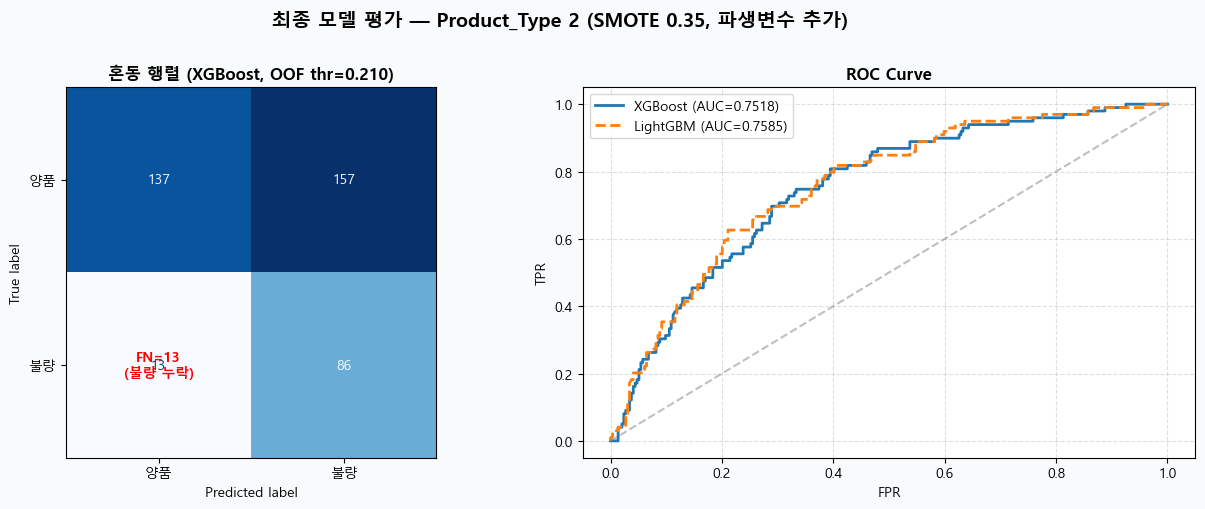

In [27]:
# XGBoost 최종 모델 (SMOTE 0.35, 파생변수 추가 버전)
# 임계값: OOF로 결정 (ad1fbec6에서 계산, test 정보 불사용)

best_xgb_final = all_best_models['SMOTE 0.35']['XGBoost']
best_lgb_ref   = all_best_models['SMOTE 0.35']['LightGBM']
opt_thr_xgb    = all_oof_thresholds['SMOTE 0.35']['XGBoost']

y_prob_final = best_xgb_final.predict_proba(X_test_xgb)[:, 1]
y_pred_final = (y_prob_final >= opt_thr_xgb).astype(int)

print("=" * 55)
print(f"  최종 모델: XGBoost (SMOTE 0.35, 임계값 {opt_thr_xgb:.3f}, OOF 기준)")
print(f"  피처: {len(FEATURES)}개 (원본 21 + 파생변수 {len(FEATURES)-21}개)")
print("=" * 55)
print(classification_report(
    y_test, y_pred_final,
    target_names=['양품', '불량'],
    digits=4
))

# 혼동행렬 + ROC
y_prob_lgb_ref = best_lgb_ref.predict_proba(X_test)[:, 1]
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_final)
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lgb_ref)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)

tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'혼동 행렬 (XGBoost, OOF thr={opt_thr_xgb:.3f})', fontweight='bold')
axes[0].text(
    0, 1, f'FN={fn}\n(불량 누락)',
    ha='center', va='center',
    fontsize=10, color='red', fontweight='bold'
)

axes[1].plot(
    fpr_x, tpr_x, lw=2,
    label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_final):.4f})'
)
axes[1].plot(
    fpr_l, tpr_l, lw=2, linestyle='--',
    label=f'LightGBM (AUC={roc_auc_score(y_test, y_prob_lgb_ref):.4f})'
)
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle(
    '최종 모델 평가 — Product_Type 2 (SMOTE 0.35, 파생변수 추가)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## STEP 6. SHAP

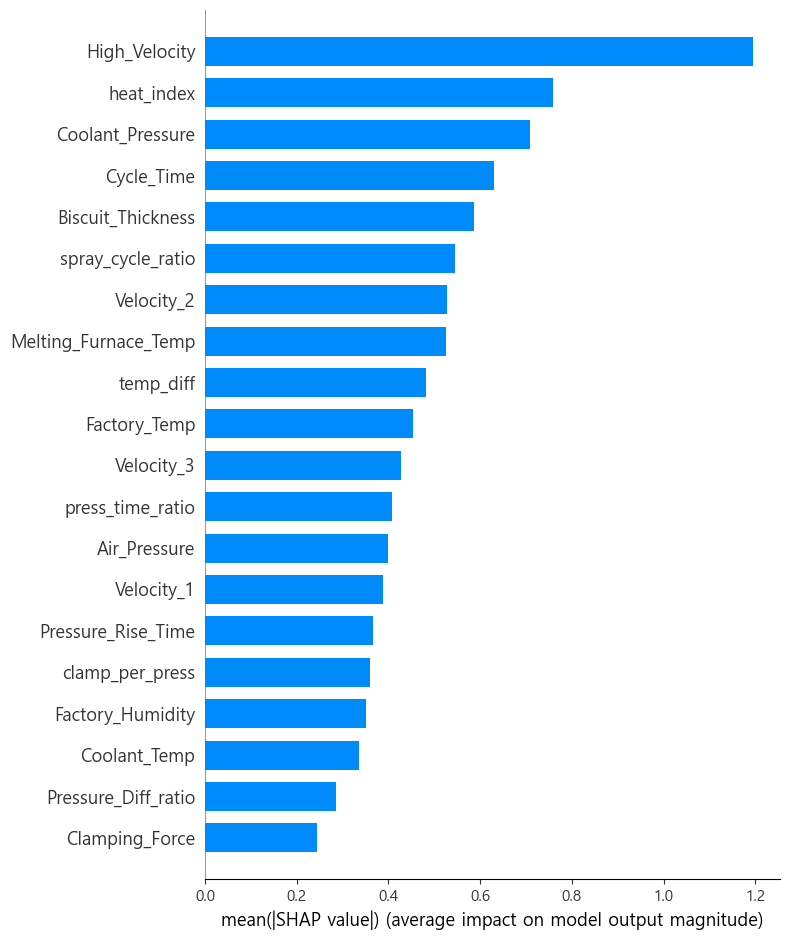

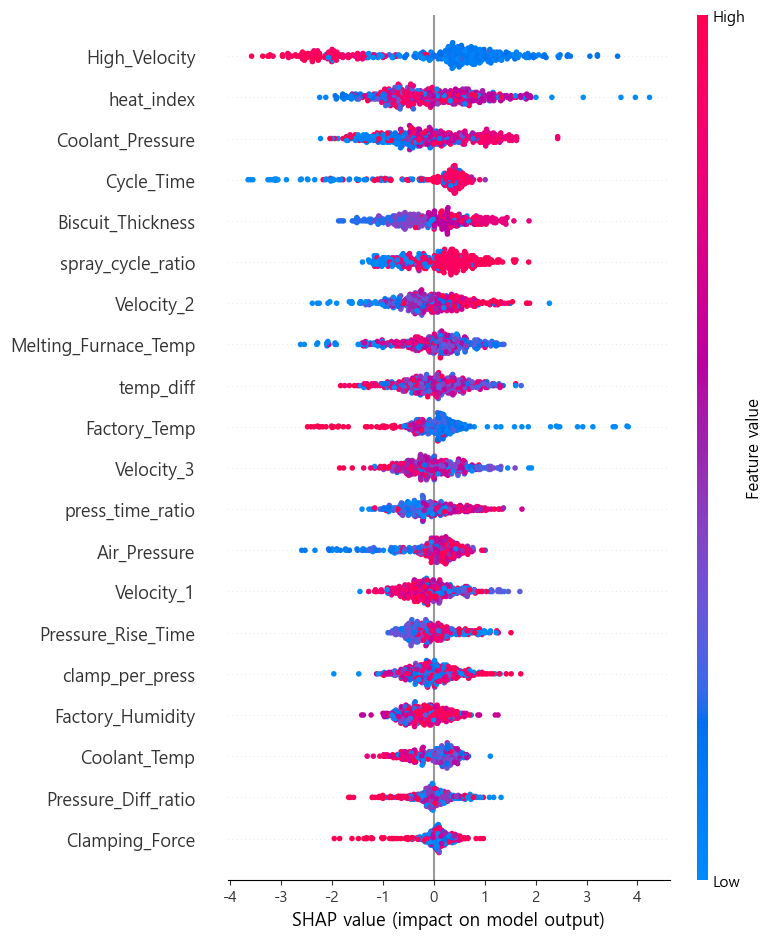

In [28]:
import shap
import warnings
warnings.filterwarnings('ignore')

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)
shap_values_array = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_values_array, X_test, plot_type='bar', show=True)
shap.summary_plot(shap_values_array, X_test, show=True)

## STEP 7. Isolation Forest + XGBoost 2단계 파이프라인

In [30]:
from sklearn.ensemble import IsolationForest

# OOF 임계값 재사용 (ad1fbec6에서 계산됨)
# opt_thr_xgb는 STEP 5에서 oof_thresholds['XGBoost']로 이미 설정됨

# Stage 1: Isolation Forest (양품 데이터로만 학습)
X_train_normal = X_train[y_train == 0]

iso_pipe = IsolationForest(random_state=SEED)
iso_pipe.fit(X_train_normal)

X_train_if = X_train.copy()
X_test_if  = X_test.copy()

X_train_if['anomaly_score'] = iso_pipe.decision_function(X_train)
X_test_if['anomaly_score']  = iso_pipe.decision_function(X_test)

print("[ Isolation Forest 이상치 점수 통계 ]")
print(f"양품 평균: {X_train_if[y_train==0]['anomaly_score'].mean():.4f}")
print(f"불량 평균: {X_train_if[y_train==1]['anomaly_score'].mean():.4f}")

from imblearn.over_sampling import SMOTE
smote_if = SMOTE(sampling_strategy=0.35, random_state=SEED)
X_train_if_sm, y_train_if_sm = smote_if.fit_resample(X_train_if, y_train)

# XGBoost 입력용 one-hot 정렬
X_train_if_sm_xgb = pd.get_dummies(X_train_if_sm)
X_test_if_xgb = pd.get_dummies(X_test_if).reindex(columns=X_train_if_sm_xgb.columns, fill_value=0)

# 기존 최적 XGBoost 파라미터 재사용
xgb_if = xgb.XGBClassifier(**best_xgb_final.get_params())
xgb_if.fit(X_train_if_sm_xgb, y_train_if_sm)

# IF 포함 모델 임계값도 OOF로 결정
X_train_if_reset = X_train_if.reset_index(drop=True)
y_train_reset    = y_train.reset_index(drop=True)
thr_if = find_threshold_from_oof_smote(
    xgb_if, X_train_if_reset, y_train_reset, strategy=0.35)

y_prob_if  = xgb_if.predict_proba(X_test_if)[:, 1]
y_pred_if  = (y_prob_if >= thr_if).astype(int)
r_if  = recall_score(y_test, y_pred_if, zero_division=0)
p_if  = precision_score(y_test, y_pred_if, zero_division=0)
f1_if = f1_score(y_test, y_pred_if, zero_division=0)
auc_if = roc_auc_score(y_test, y_prob_if)
ok_if  = r_if >= 0.80

print("\n[ 단일 XGBoost vs IF 점수 추가 XGBoost 비교 (OOF 임계값) ]")
compare_df = pd.DataFrame([
    {'모델': 'XGBoost (단독)', '임계값(OOF)': round(opt_thr_xgb, 2),
     'Recall': round(recall_score(y_test, y_pred_final), 4),
     'F1-Score': round(f1_score(y_test, y_pred_final), 4),
     'ROC-AUC': round(roc_auc_score(y_test, y_prob_final), 4), 'Recall≥0.80': '✅'},
    {'모델': 'XGBoost + IF 점수', '임계값(OOF)': round(thr_if, 2),
     'Recall': round(r_if, 4), 'F1-Score': round(f1_if, 4),
     'ROC-AUC': round(auc_if, 4), 'Recall≥0.80': '✅' if ok_if else '❌'},
])
display(compare_df)

[ Isolation Forest 이상치 점수 통계 ]
양품 평균: 0.0398
불량 평균: 0.0442

[ 단일 XGBoost vs IF 점수 추가 XGBoost 비교 (OOF 임계값) ]


,모델,임계값(OOF),Recall,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost (단독),0.21,0.8687,0.5029,0.7518,✅
1,XGBoost + IF 점수,0.21,0.8788,0.5257,0.7445,✅


## STEP 8. 캐스케이드 파이프라인 (XGBoost → LightGBM)

In [40]:
# =======================================================
# STEP 8. 캐스케이드 파이프라인
#
# [Stage 1] XGBoost (Recall 0.90 목표)
#   - 넓게 잡아라 → 불량 의심 샘플 플래깅
#
# [Stage 2] 튜닝된 LightGBM
#   - Stage 1이 플래깅한 샘플만 대상
#   - 진짜 불량 vs 과탐지 구분 → Precision 향상
# =======================================================

# 비교용 XGBoost 기준 모델/threshold 불러오기
best_xgb_ref = all_best_models['SMOTE 0.35']['XGBoost']
opt_thr_xgb = all_oof_thresholds['SMOTE 0.35']['XGBoost']

# -------------------------------------------
# Stage 1: XGBoost - Recall 0.90 목표 임계값 탐색
# -------------------------------------------
y_prob_s1 = best_xgb_ref.predict_proba(X_test_xgb)[:, 1]
thr_s1, r_s1, p_s1, f1_s1, _ = find_best_threshold_constrained(
    y_test, y_prob_s1, target_recall=0.90
)

y_pred_s1_test = (y_prob_s1 >= thr_s1).astype(int)

# 훈련 데이터도 Stage 1로 플래깅
y_prob_s1_train = best_xgb_ref.predict_proba(X_train_xgb)[:, 1]
y_pred_s1_train = (y_prob_s1_train >= thr_s1).astype(int)

print("[ Stage 1: XGBoost ]")
print(f"임계값: {thr_s1:.2f} | Recall: {r_s1:.4f} | Precision: {p_s1:.4f} | F1: {f1_s1:.4f}")
print(f"플래깅된 테스트 샘플: {y_pred_s1_test.sum()}건 / {len(y_pred_s1_test)}건")

# -------------------------------------------
# Stage 2: LightGBM - Stage 1 플래깅 샘플로만 재학습
# -------------------------------------------
X_train_s2 = X_train[y_pred_s1_train == 1]
y_train_s2 = y_train[y_pred_s1_train == 1]

print(f"\n[ Stage 2: LightGBM 학습 데이터 ]")
print(f"플래깅된 훈련 샘플: {len(X_train_s2)}건 "
      f"(양품 {(y_train_s2==0).sum()} / 불량 {(y_train_s2==1).sum()})")

best_lgb_ref = all_best_models['SMOTE 0.35']['LightGBM']
lgb_s2 = lgb.LGBMClassifier(**best_lgb_ref.get_params())
lgb_s2.fit(X_train_s2, y_train_s2)

# -------------------------------------------
# 최종 예측: Stage 1 플래깅 → Stage 2 분류
# -------------------------------------------
X_test_s1_pos = X_test[y_pred_s1_test == 1]

y_prob_final = np.zeros(len(X_test))
y_prob_final[y_pred_s1_test == 1] = lgb_s2.predict_proba(X_test_s1_pos)[:, 1]

thr_final, r_final, p_final, f1_final, ok_final = find_best_threshold_constrained(y_test, y_prob_final)
auc_final = roc_auc_score(y_test, y_prob_final)

# -------------------------------------------
# 단독 XGBoost 성능도 실제 계산
# -------------------------------------------
y_prob_xgb = best_xgb_ref.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb = (y_prob_xgb >= opt_thr_xgb).astype(int)

r_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
p_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# -------------------------------------------
# 비교 테이블
# -------------------------------------------
print("\n[ 단독 XGBoost vs 캐스케이드 파이프라인 비교 ]")
compare_df = pd.DataFrame([
    {
        '모델': 'XGBoost (단독)',
        '임계값': round(opt_thr_xgb, 2),
        'Recall': round(r_xgb, 4),
        'Precision': round(p_xgb, 4),
        'F1-Score': round(f1_xgb, 4),
        'ROC-AUC': round(auc_xgb, 4),
        'Recall≥0.80': '✅' if r_xgb >= 0.80 else '❌'
    },
    {
        '모델': 'Stage1 XGBoost (Recall0.90)',
        '임계값': round(thr_s1, 2),
        'Recall': round(r_s1, 4),
        'Precision': round(p_s1, 4),
        'F1-Score': round(f1_s1, 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob_s1), 4),
        'Recall≥0.80': '✅' if r_s1 >= 0.80 else '❌'
    },
    {
        '모델': 'XGBoost → LightGBM (캐스케이드)',
        '임계값': round(thr_final, 2),
        'Recall': round(r_final, 4),
        'Precision': round(p_final, 4),
        'F1-Score': round(f1_final, 4),
        'ROC-AUC': round(auc_final, 4),
        'Recall≥0.80': '✅' if ok_final else '❌'
    },
])
display(compare_df)

[ Stage 1: XGBoost ]
임계값: 0.18 | Recall: 0.9293 | Precision: 0.3297 | F1: 0.4868
플래깅된 테스트 샘플: 279건 / 393건

[ Stage 2: LightGBM 학습 데이터 ]
플래깅된 훈련 샘플: 996건 (양품 608 / 불량 388)

[ 단독 XGBoost vs 캐스케이드 파이프라인 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,XGBoost (단독),0.21,0.8687,0.3539,0.5029,0.7518,✅
1,Stage1 XGBoost (Recall0.90),0.18,0.9293,0.3297,0.4868,0.7518,✅
2,XGBoost → LightGBM (캐스케이드),0.24,0.8788,0.3734,0.5241,0.7312,✅


## STEP 9. 불량 유형 다중 분류 (Defect_Type)

[ 원본 클래스 분포 ]
Defect_Type
Normal        1467
Short_Shot     222
Blow_Hole      169
Bubble           1
Name: count, dtype: int64

[ 사용 클래스 분포 (2개 이상만 유지) ]
Defect_Type
Normal        1467
Short_Shot     222
Blow_Hole      169
Name: count, dtype: int64

전체 샘플: 1858건

[ 라벨 인코딩 매핑 ]
0 -> Blow_Hole
1 -> Normal
2 -> Short_Shot

훈련셋: 1486행 / 테스트셋: 372행

[ XGBoost 다중 분류 성능 ]
              precision    recall  f1-score   support

   Blow_Hole     0.2941    0.1471    0.1961        34
      Normal     0.8101    0.9286    0.8653       294
  Short_Shot     0.2778    0.1136    0.1613        44

    accuracy                         0.7608       372
   macro avg     0.4607    0.3964    0.4076       372
weighted avg     0.7000    0.7608    0.7209       372



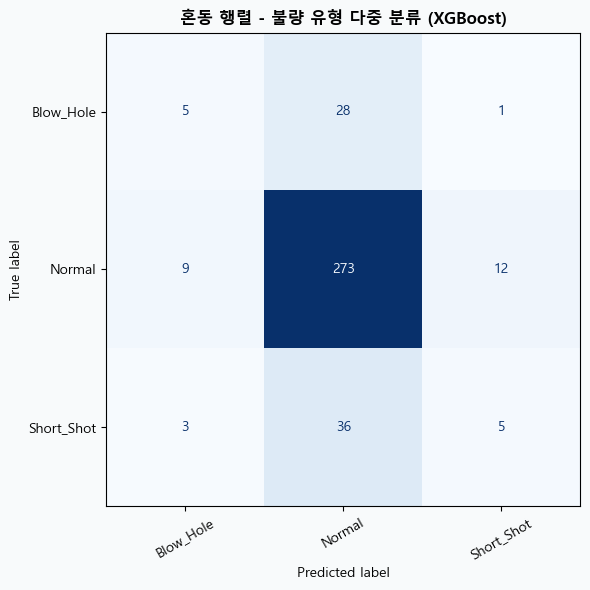

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# 파생변수 추가 버전 CSV 사용
type2_multi = pd.read_csv('../../data/df_type2_파생변수추가.csv')
type2_multi['Pressure_Diff_ratio'] = type2_multi['Casting_Pressure'] / type2_multi['Cylinder_Pressure']

# Other, Stain 제외
type2_multi = type2_multi[~type2_multi['Defect_Type'].isin(['Other', 'Stain'])].reset_index(drop=True)

# 클래스 개수 확인 후 2개 미만 클래스 제거
class_counts = type2_multi['Defect_Type'].value_counts()
print("[ 원본 클래스 분포 ]")
print(class_counts)

valid_classes = class_counts[class_counts >= 2].index
type2_multi = type2_multi[type2_multi['Defect_Type'].isin(valid_classes)].reset_index(drop=True)

print("\n[ 사용 클래스 분포 (2개 이상만 유지) ]")
print(type2_multi['Defect_Type'].value_counts())

X_multi = type2_multi[FEATURES].copy()
y_multi = type2_multi['Defect_Type'].copy()

print(f"\n전체 샘플: {len(y_multi)}건")

# ✅ 문자열 라벨 → 숫자 라벨 변환
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print("\n[ 라벨 인코딩 매핑 ]")
for i, cls in enumerate(le.classes_):
    print(f"{i} -> {cls}")

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_multi, y_multi_enc, test_size=0.2, stratify=y_multi_enc, random_state=SEED
)
print(f"\n훈련셋: {X_tr_m.shape[0]}행 / 테스트셋: {X_te_m.shape[0]}행")

# XGBoost용 원-핫
X_tr_m_xgb = pd.get_dummies(X_tr_m)
X_te_m_xgb = pd.get_dummies(X_te_m).reindex(columns=X_tr_m_xgb.columns, fill_value=0)

xgb_multi = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=SEED,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_multi.fit(X_tr_m_xgb, y_tr_m)
y_pred_multi = xgb_multi.predict(X_te_m_xgb)

# ✅ 숫자 라벨 다시 원래 클래스명으로 복원
y_te_labels = le.inverse_transform(y_te_m)
y_pred_labels = le.inverse_transform(y_pred_multi)

print("\n[ XGBoost 다중 분류 성능 ]")
print(classification_report(y_te_labels, y_pred_labels, digits=4))

labels = list(le.classes_)
cm_multi = confusion_matrix(y_te_labels, y_pred_labels, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F8FAFB')
ConfusionMatrixDisplay(cm_multi, display_labels=labels).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30
)
ax.set_title('혼동 행렬 - 불량 유형 다중 분류 (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9-1. 불량 유형 다중 분류 — Normal 제외 (불량끼리만)

[ 클래스 분포 (Normal 제외) ]
Defect_Type
Short_Shot    222
Blow_Hole     169
Name: count, dtype: int64

전체 샘플: 391건

[ 라벨 인코딩 매핑 ]
0 -> Blow_Hole
1 -> Short_Shot

훈련셋: 312행 / 테스트셋: 79행

[ 베이스라인 (SMOTE 없음) ]
              precision    recall  f1-score   support

   Blow_Hole     0.6471    0.6471    0.6471        34
  Short_Shot     0.7333    0.7333    0.7333        45

    accuracy                         0.6962        79
   macro avg     0.6902    0.6902    0.6902        79
weighted avg     0.6962    0.6962    0.6962        79

[ SMOTE 후 클래스 분포 ]
Short_Shot    177
Blow_Hole     177
Name: count, dtype: int64

[ SMOTE 적용 후 ]
              precision    recall  f1-score   support

   Blow_Hole     0.6562    0.6176    0.6364        34
  Short_Shot     0.7234    0.7556    0.7391        45

    accuracy                         0.6962        79
   macro avg     0.6898    0.6866    0.6877        79
weighted avg     0.6945    0.6962    0.6949        79



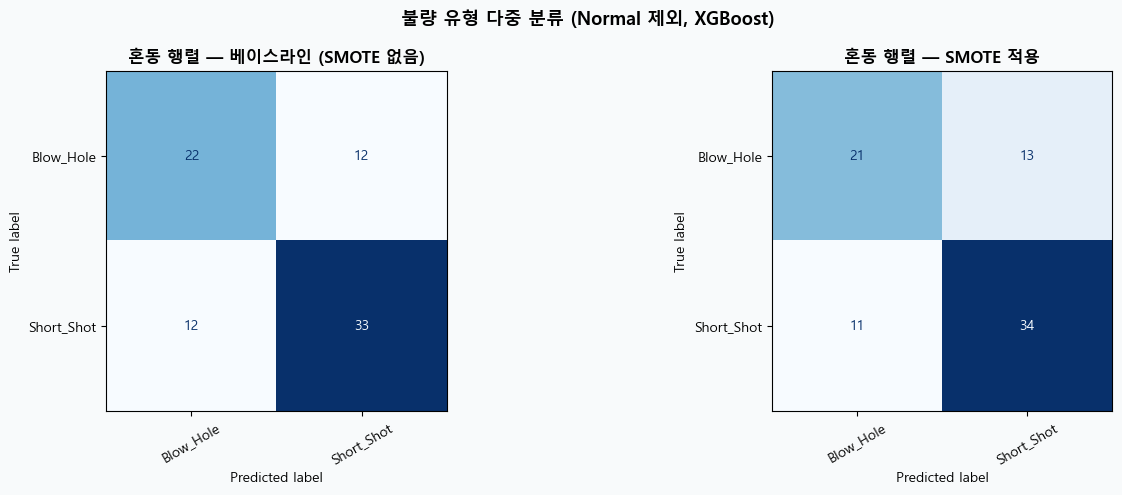

In [38]:
from imblearn.over_sampling import SMOTE

# type2_multi는 바로 위 STEP 9에서 이미 로드됨 (파생변수 추가 버전)
type2_defect = type2_multi[type2_multi['Defect_Type'] != 'Normal'].reset_index(drop=True)

X_def = type2_defect[FEATURES].copy()
y_def = type2_defect['Defect_Type'].copy()

print("[ 클래스 분포 (Normal 제외) ]")
print(y_def.value_counts())
print(f"\n전체 샘플: {len(y_def)}건")

# 문자열 라벨 → 숫자 라벨
le_def = LabelEncoder()
y_def_enc = le_def.fit_transform(y_def)

print("\n[ 라벨 인코딩 매핑 ]")
for i, cls in enumerate(le_def.classes_):
    print(f"{i} -> {cls}")

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_def, y_def_enc, test_size=0.2, stratify=y_def_enc, random_state=SEED
)
print(f"\n훈련셋: {X_tr_d.shape[0]}행 / 테스트셋: {X_te_d.shape[0]}행")

# XGBoost용 원-핫
X_tr_d_xgb = pd.get_dummies(X_tr_d)
X_te_d_xgb = pd.get_dummies(X_te_d).reindex(columns=X_tr_d_xgb.columns, fill_value=0)

# -----------------------------
# 베이스라인
# -----------------------------
xgb_def = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_def.classes_),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=SEED,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_def.fit(X_tr_d_xgb, y_tr_d)
y_pred_def = xgb_def.predict(X_te_d_xgb)

# 원래 라벨명 복원
y_te_d_label = le_def.inverse_transform(y_te_d)
y_pred_def_label = le_def.inverse_transform(y_pred_def)

print("\n[ 베이스라인 (SMOTE 없음) ]")
print(classification_report(y_te_d_label, y_pred_def_label, digits=4))

# -----------------------------
# SMOTE 적용
# -----------------------------
smote_def = SMOTE(random_state=SEED, k_neighbors=3)
X_tr_d_sm, y_tr_d_sm = smote_def.fit_resample(X_tr_d, y_tr_d)

print("[ SMOTE 후 클래스 분포 ]")
print(pd.Series(le_def.inverse_transform(y_tr_d_sm)).value_counts())

# SMOTE 후 XGBoost용 원-핫
X_tr_d_sm_xgb = pd.get_dummies(X_tr_d_sm)
X_te_d_sm_xgb = pd.get_dummies(X_te_d).reindex(columns=X_tr_d_sm_xgb.columns, fill_value=0)

xgb_def_sm = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_def.classes_),
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=SEED,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_def_sm.fit(X_tr_d_sm_xgb, y_tr_d_sm)
y_pred_def_sm = xgb_def_sm.predict(X_te_d_sm_xgb)

y_pred_def_sm_label = le_def.inverse_transform(y_pred_def_sm)

print("\n[ SMOTE 적용 후 ]")
print(classification_report(y_te_d_label, y_pred_def_sm_label, digits=4))

# -----------------------------
# 혼동행렬 비교
# -----------------------------
labels_def = list(le_def.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

for ax, y_pred_plot, title in zip(
    axes,
    [y_pred_def_label, y_pred_def_sm_label],
    ['베이스라인 (SMOTE 없음)', 'SMOTE 적용']
):
    cm_def = confusion_matrix(y_te_d_label, y_pred_plot, labels=labels_def)
    ConfusionMatrixDisplay(cm_def, display_labels=labels_def).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30
    )
    ax.set_title(f'혼동 행렬 — {title}', fontweight='bold')

plt.suptitle('불량 유형 다중 분류 (Normal 제외, XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9 결론 — 불량 유형 분류 한계 및 방향 전환

### 실험 요약

| 실험 | 조건 | macro F1 | 비고 |
|------|------|----------|------|
| STEP 9 | Normal 포함, 5클래스 | 0.338 | Normal만 F1=0.827, 나머지 0.13~0.39 |
| STEP 9-1 (베이스라인) | Normal 제외, 4클래스 | 0.376 | 4클래스 랜덤 기준(0.25) 대비 소폭 상회 |
| STEP 9-1 (SMOTE) | Normal 제외 + SMOTE | 0.395 | 최선의 시도, 실용성 없음 |

### 실패 원인

1. **절대 샘플 수 부족** — Bubble 58건(훈련셋 46건), 테스트셋 12건으로 어떤 모델도 학습 불가
2. **유형간 공정 패턴 유사** — Exfoliation/Short_Shot/Deformation 모두 비슷한 공정 조건에서 발생, 피처로 구분되는 신호 없음
3. **미수집 변수 영향 가능성** — 불량 유형은 금형 상태, 재료 배치, 작업자 등 공정 수치 외 요인에 의존할 가능성

### 방향 전환

불량 유형 분류 대신 아래 두 축으로 목표 재설정:

- **이진 분류 (불량 여부)** — LightGBM, Recall ≥ 0.80 달성 → 실용적 조기 경보 가능
- **SHAP 기반 유형 간접 해석** — Type 1 vs Type 2 중요 변수 비교로 불량 발생 메커니즘 차이 분석

> 공정 데이터만으로 불량 유형을 구분하는 것은 현재 데이터셋의 구조적 한계이며,
> 불량 탐지 자체의 신뢰도(Recall 0.80 이상)를 확보하는 것이 현실적 목표.

In [15]:
#with open('model_type1_lgbm.pkl', 'wb') as f:
    #pickle.dump({'model': best_lgb, 'threshold': float(opt_thr_lgbm), 'features': list(X_train.columns)}, f)

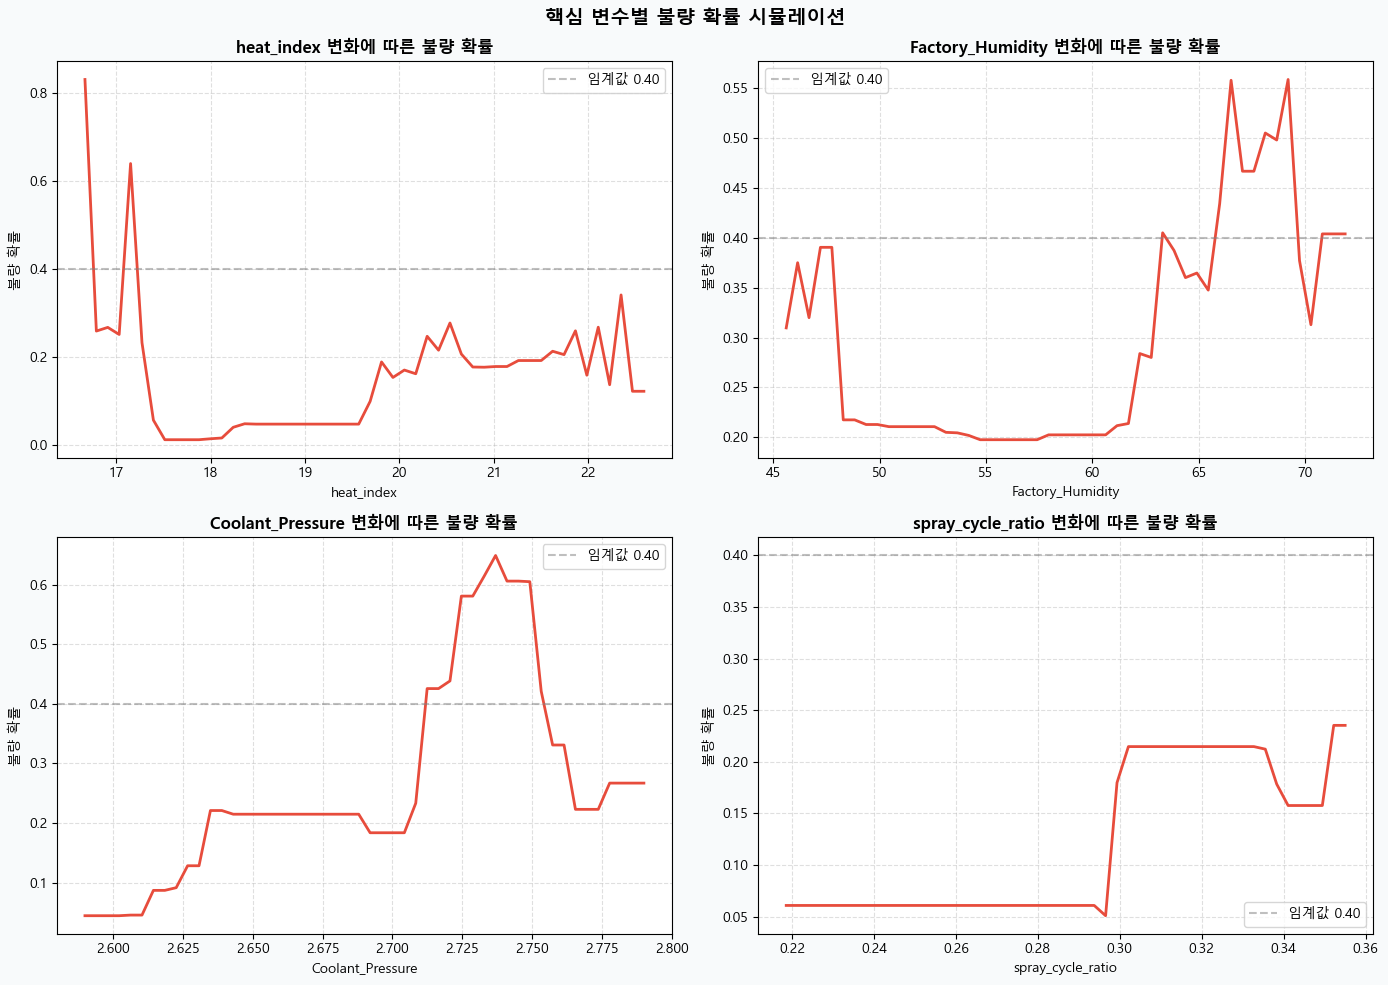

  최적 공정 조건 (불량 확률 하위 10%)
      heat_index  Factory_Humidity  Coolant_Pressure  spray_cycle_ratio  불량확률
mean     18.1159           51.3621            2.6976             0.3042   0.0
min      17.0200           46.0000            2.6200             0.2941   0.0
max      20.7025           63.7000            2.7600             0.3470   0.0

 최적 조건 요약:
  heat_index: 18.12 (범위 17.02 ~ 20.70)
  Factory_Humidity: 51.36 (범위 46.00 ~ 63.70)
  Coolant_Pressure: 2.70 (범위 2.62 ~ 2.76)
  spray_cycle_ratio: 0.30 (범위 0.29 ~ 0.35)


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# 기준값: 양품 데이터 평균
# -------------------------------------------
baseline = X_test[y_test == 0].mean().to_dict()

# -------------------------------------------
# 1. 시나리오 시뮬레이션
# 핵심 변수별 구간 변화 → 불량 확률 변화
# -------------------------------------------
key_vars = ['heat_index', 'Factory_Humidity', 'Coolant_Pressure', 'spray_cycle_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(key_vars):
    probs = []
    var_range = np.linspace(X_test[var].min(), X_test[var].max(), 50)
    
    for val in var_range:
        sample = pd.DataFrame([baseline])
        sample[var] = val
        prob = best_lgb.predict_proba(sample)[:,1][0]
        probs.append(prob)
    
    axes[i].plot(var_range, probs, color='#E74C3C', lw=2)
    axes[i].axhline(0.4, color='gray', linestyle='--', alpha=0.5, label='임계값 0.40')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('불량 확률')
    axes[i].set_title(f'{var} 변화에 따른 불량 확률', fontweight='bold')
    axes[i].legend()
    axes[i].grid(linestyle='--', alpha=0.4)

plt.suptitle('핵심 변수별 불량 확률 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------
# 2. 최적 공정 조건 탐색
# 양품 데이터 중 불량 확률 최저 구간 추출
# -------------------------------------------
normal_data = X_test[y_test == 0].copy()
normal_data['불량확률'] = best_lgb.predict_proba(normal_data)[:,1]
normal_data = normal_data.sort_values('불량확률')

print("=" * 55)
print("  최적 공정 조건 (불량 확률 하위 10%)")
print("=" * 55)
top10 = normal_data.head(int(len(normal_data) * 0.1))
optimal = top10[key_vars + ['불량확률']].describe().loc[['mean', 'min', 'max']]
print(optimal.round(4))

print("\n 최적 조건 요약:")
for var in key_vars:
    print(f"  {var}: {top10[var].mean():.2f} (범위 {top10[var].min():.2f} ~ {top10[var].max():.2f})")

## STEP 10. SHAP Dependence Plot

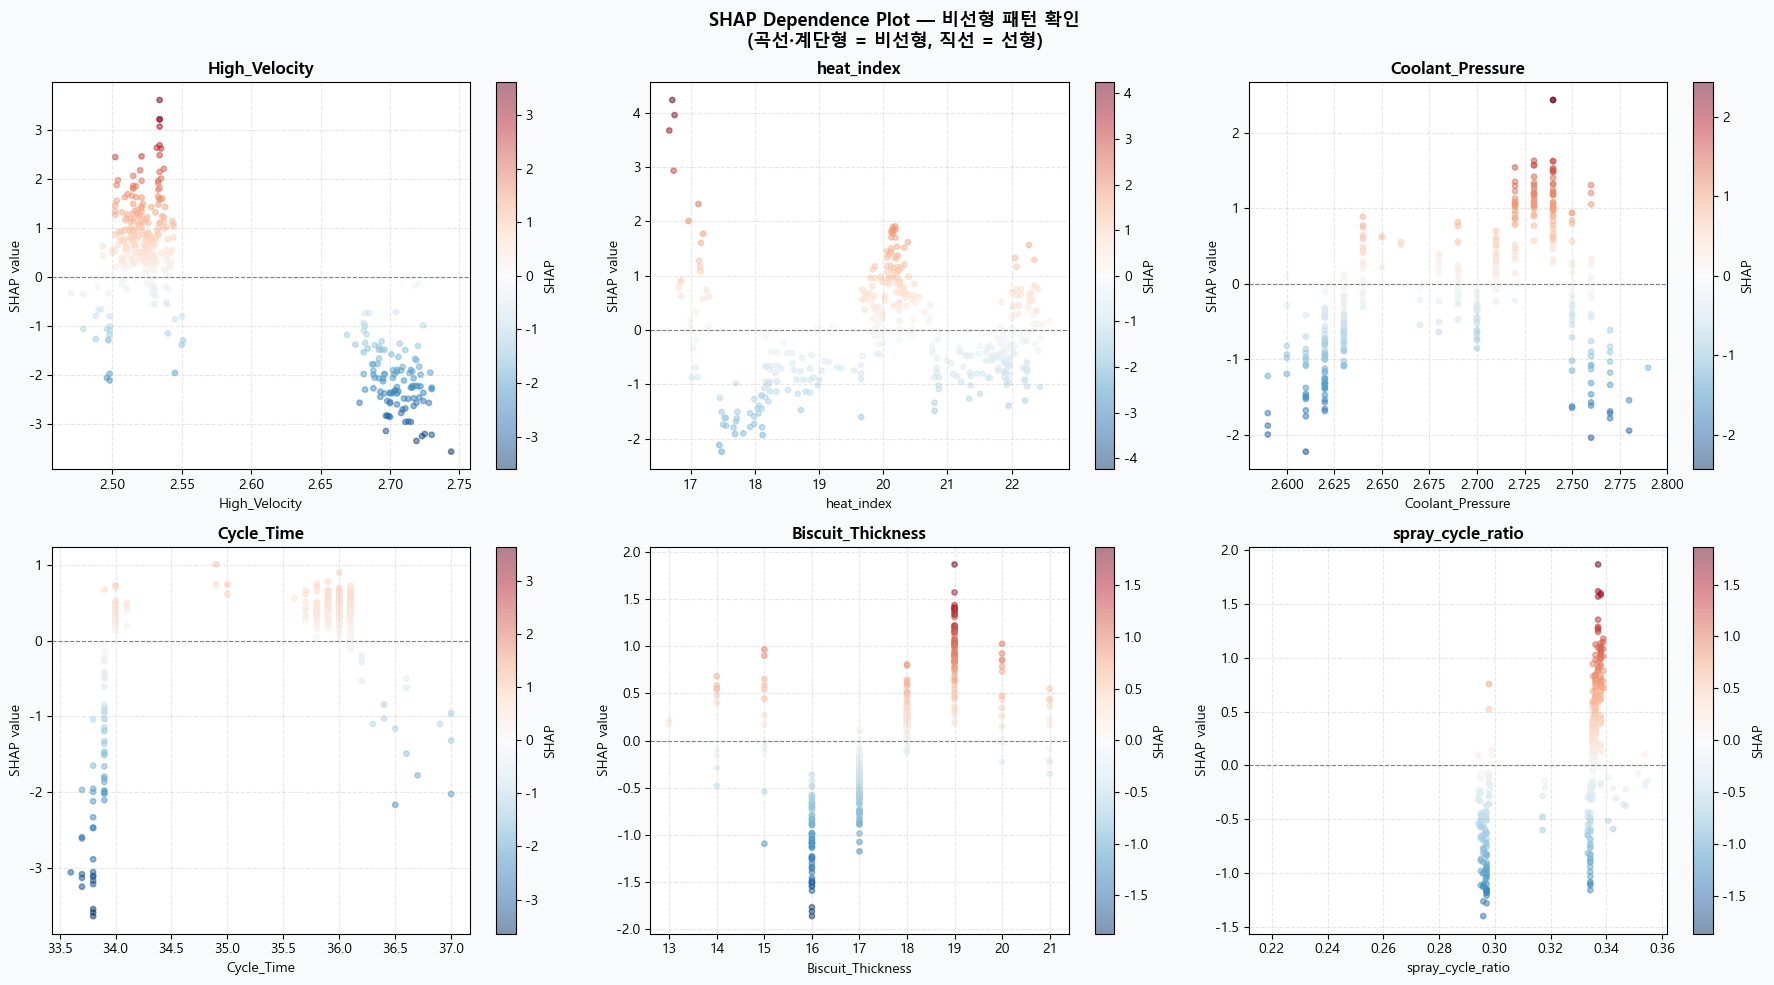

※ 해석 가이드
  - SHAP > 0 : 불량 확률 증가 기여
  - SHAP < 0 : 불량 확률 감소 기여
  - x값에 따라 SHAP 부호/크기가 불규칙하게 변하면 → 비선형 관계


In [42]:
# ── SHAP Dependence Plot
# x축: 변수값, y축: SHAP 기여도
# 직선 → 선형 관계 / 곡선·계단 → 비선형 관계
# Spearman(선형 상관)과 SHAP 순위 차이가 큰 변수에서 비선형 패턴 확인

# SHAP 상위 + 파생변수 중심으로 선택
dep_vars = ['High_Velocity', 'heat_index', 'Coolant_Pressure', 'Cycle_Time', 'Biscuit_Thickness', 'spray_cycle_ratio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(dep_vars):
    feat_idx = list(X_test.columns).index(var)
    shap_col  = shap_values_array[:, feat_idx]
    feat_vals = X_test[var].values

    sc = axes[i].scatter(feat_vals, shap_col,
                         c=shap_col, cmap='RdBu_r',
                         alpha=0.5, s=15, vmin=-abs(shap_col).max(), vmax=abs(shap_col).max())
    axes[i].axhline(0, color='gray', lw=0.8, linestyle='--')
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('SHAP value', fontsize=10)
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].grid(linestyle='--', alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='SHAP')

plt.suptitle('SHAP Dependence Plot — 비선형 패턴 확인\n(곡선·계단형 = 비선형, 직선 = 선형)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("※ 해석 가이드")
print("  - SHAP > 0 : 불량 확률 증가 기여")
print("  - SHAP < 0 : 불량 확률 감소 기여")
print("  - x값에 따라 SHAP 부호/크기가 불규칙하게 변하면 → 비선형 관계")